In [1]:
import csv
import pandas as pd

In [2]:
main1 = pd.read_csv("Kappa_scores_Main1.csv", delimiter=",", encoding="utf-8")
main2 = pd.read_csv("Kappa_scores_Main2.csv", delimiter=",", encoding="utf-8")
main3 = pd.read_csv("Kappa_scores_Main3.csv", delimiter=",", encoding="utf-8")
#main4 = pd.read_csv("Kappa_scores_Main4.csv", delimiter=",", encoding="utf-8")
#main5 = pd.read_csv("Kappa_scores_Main5.csv", delimiter=",", encoding="utf-8")

In [3]:
main = pd.concat([main1, main2, main3], ignore_index=True)
main.to_csv("Main.csv")
main

,Phase,Type,6-level,3-level
0,Main1,full,0.70,0.82
1,Main1,non-procedural,0.62,0.77
2,Main2,full,0.67,0.84
3,Main2,non-procedural,0.47,0.69
4,Main3,full,0.75,0.89
5,Main3,non-procedural,0.61,0.81


In [4]:
data = pd.melt(main,
               id_vars=['Phase', 'Type'],
               value_vars=['6-level', '3-level'],
               var_name = 'Level',
               value_name = 'Kappa Score'
)

data

,Phase,Type,Level,Kappa Score
0,Main1,full,6-level,0.70
1,Main1,non-procedural,6-level,0.62
2,Main2,full,6-level,0.67
3,Main2,non-procedural,6-level,0.47
4,Main3,full,6-level,0.75
5,Main3,non-procedural,6-level,0.61
6,Main1,full,3-level,0.82
7,Main1,non-procedural,3-level,0.77
8,Main2,full,3-level,0.84
9,Main2,non-procedural,3-level,0.69


# Main annotation - Kappa score analysis

New data will be added gradually as the annotation phases progress. 

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

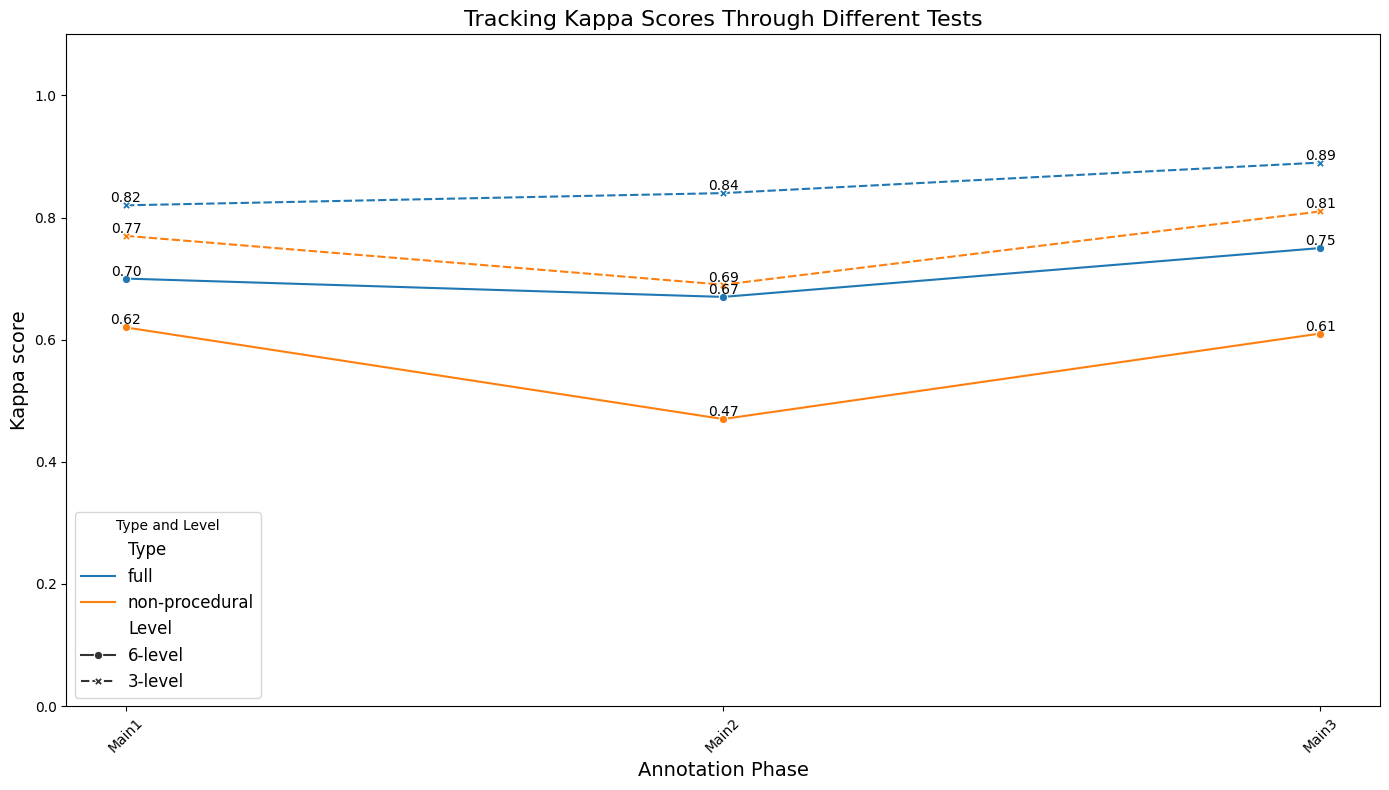

In [9]:
plt.figure(figsize=(14,8))
line_plot=sns.lineplot(data=data, x='Phase', y='Kappa Score', hue='Type', style='Level', markers=True, palette='tab10')

plt.title('Tracking Kappa Scores Through Different Tests', fontsize=16)
plt.xlabel('Annotation Phase', fontsize=14)
plt.ylabel('Kappa score', fontsize=14)
plt.legend(title='Type and Level', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

for line in line_plot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=10, ha='center', va='bottom')


plt.tight_layout()
plt.show()